In [22]:
!pip install category_encoders shap yellowbrick

In [23]:
# Librerias para manipulacion de Data y Gráficas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#Preparación de datos y configuración de pipeline para Machine Learning con scikit-learn
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import validation_curve
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

#models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
#for classification
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier

#for regression
from sklearn.metrics import r2_score

In [24]:
 #Forma 2)

# Reemplaza con el ID real de tu archivo en Drive
file_id = '1quHdlcSkxdczFZDN01xVApB45sKQPlN1'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Cargar el dataset
data = pd.read_csv(url)
data

#https://drive.google.com/file/d/1quHdlcSkxdczFZDN01xVApB45sKQPlN1/view?usp=sharing

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [26]:
# Estadística descriptiva de las features númericas
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


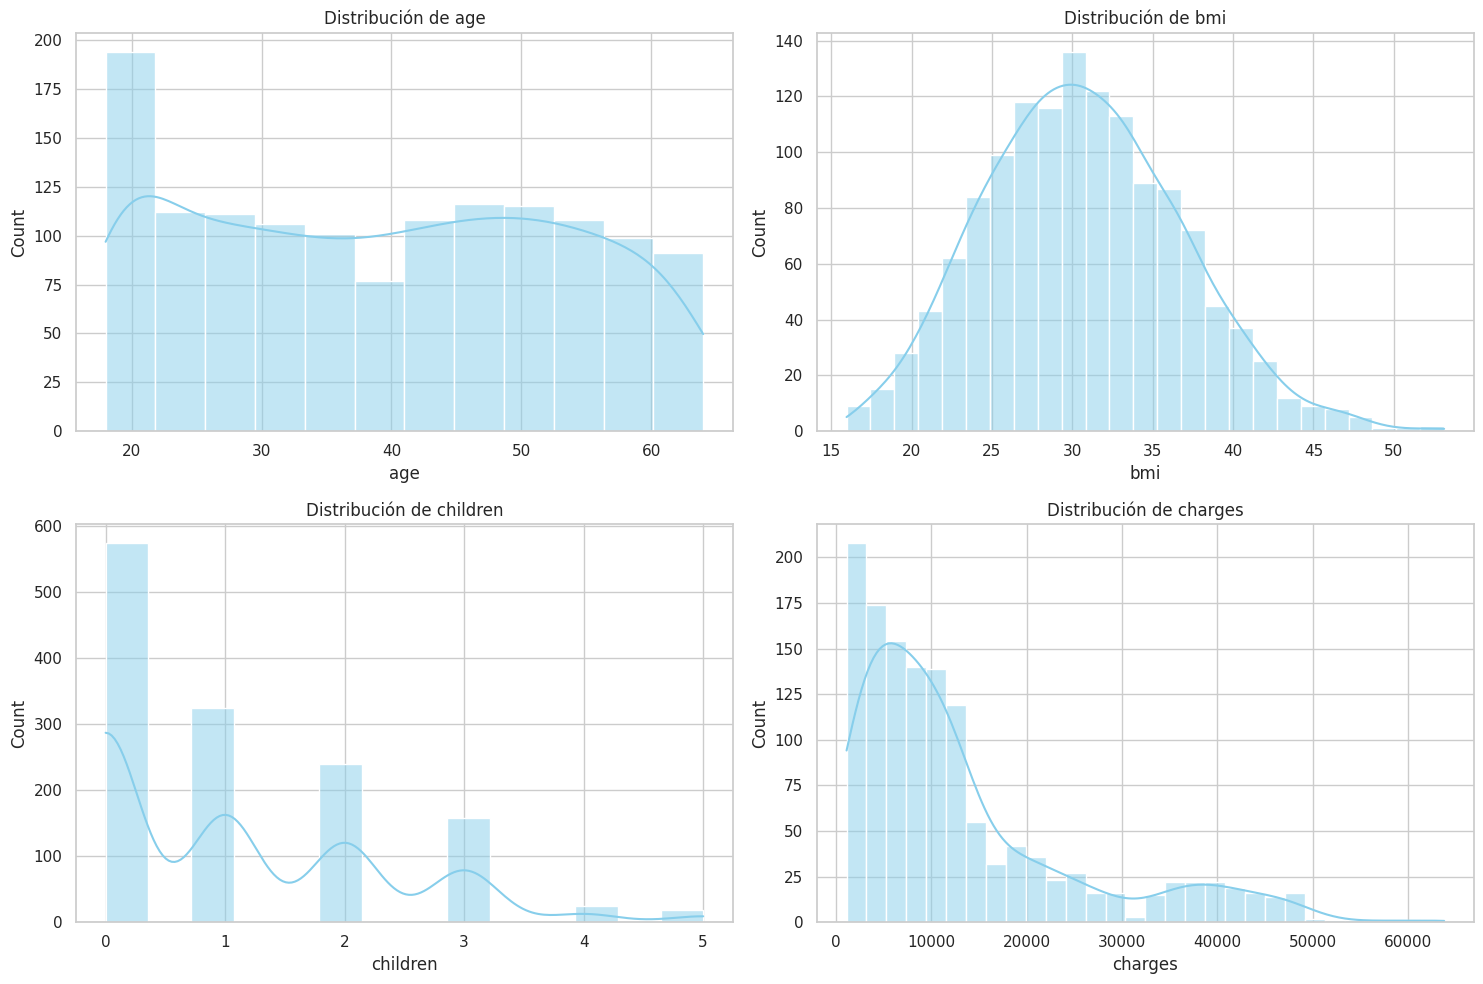

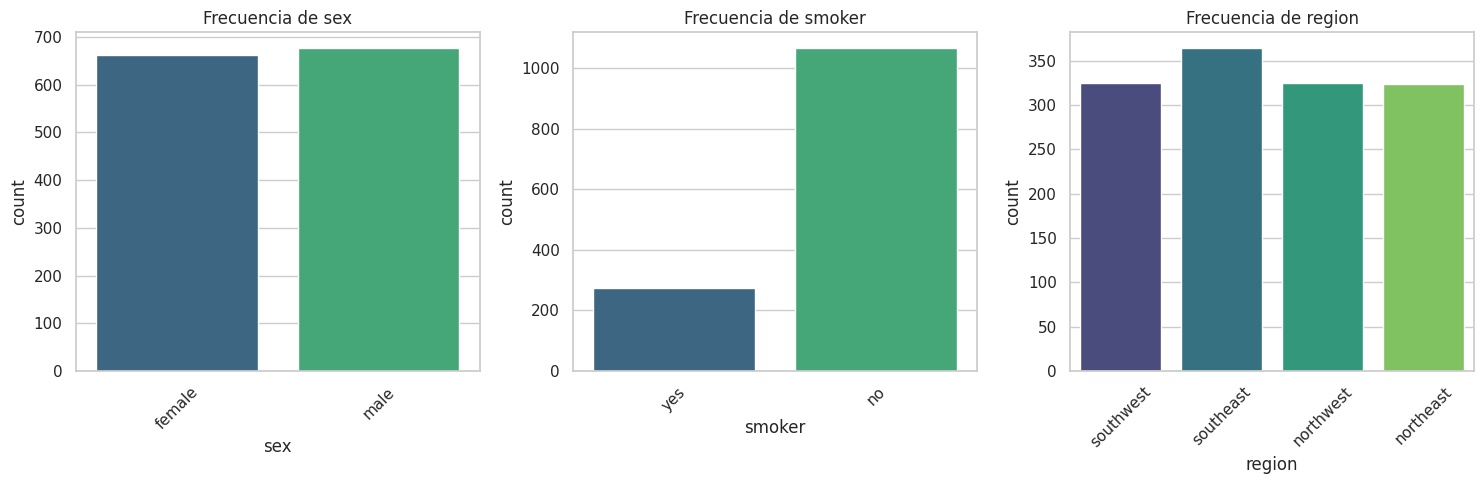

In [27]:
# Visualización de las distribuciones de los datos

# Configurar el estilo de las gráficas
sns.set(style="whitegrid")

# 1. Distribución de variables numéricas
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

# 2. Distribución de variables categóricas
categorical_cols = data.select_dtypes(include=['object']).columns
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    # Corregido: se asigna 'hue' para evitar FutureWarnings
    sns.countplot(x=col, data=data, hue=col, palette='viridis', legend=False)
    plt.title(f'Frecuencia de {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

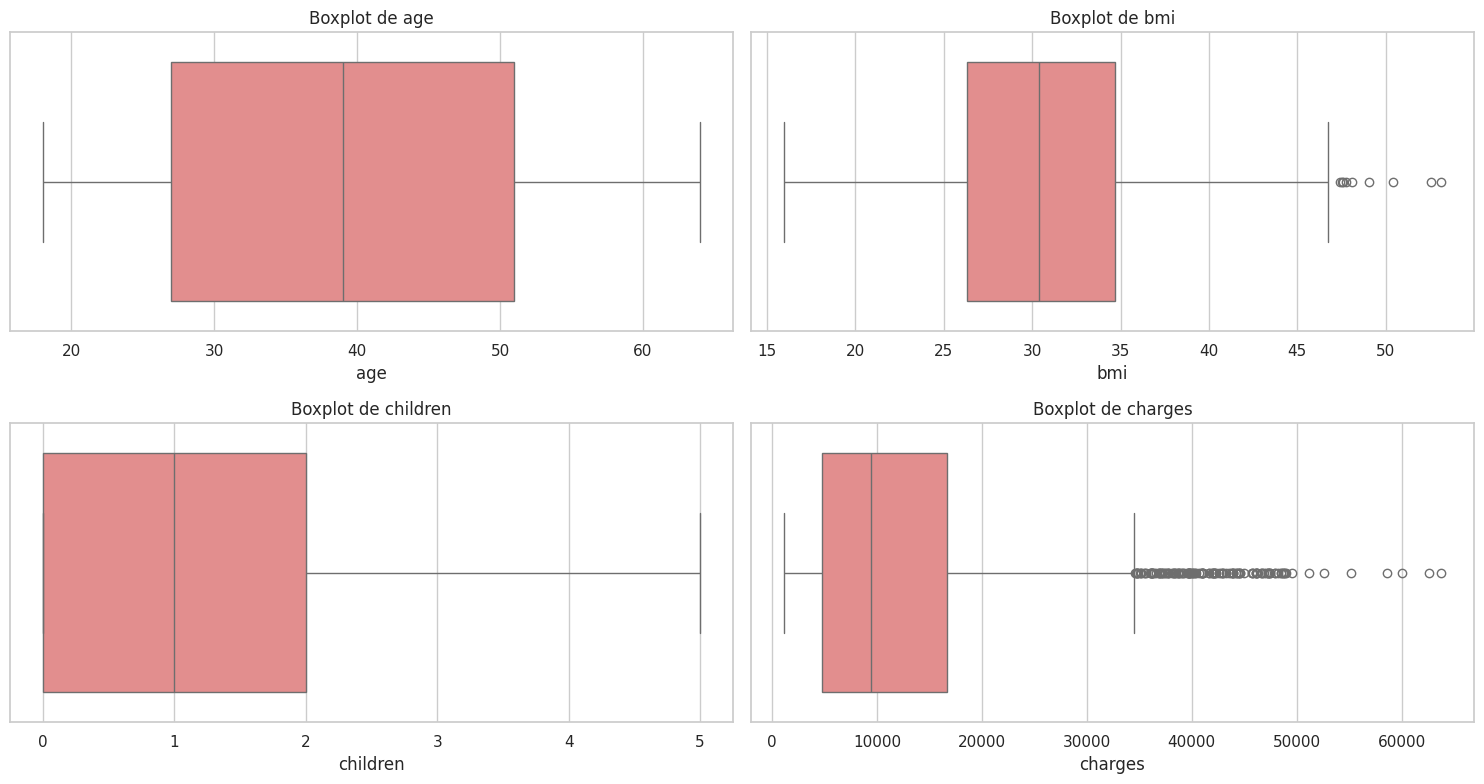

In [28]:
# Gráfica de cajas y bigotes (Boxplots) para variables numéricas
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=data[col], color='lightcoral')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

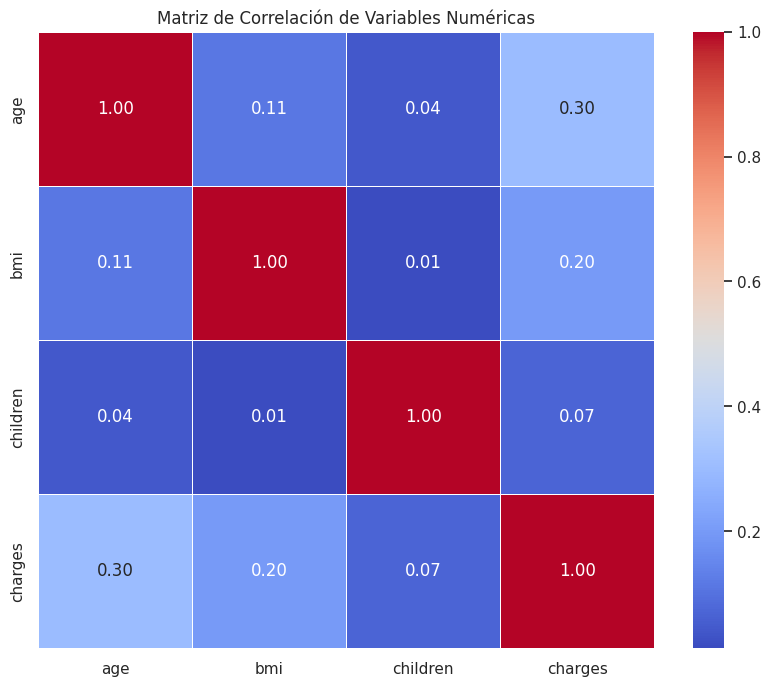

In [29]:
# Cálculo y visualización de la matriz de correlación

# Filtrar solo columnas numéricas para el cálculo
numeric_data = data.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_data.corr()

# Configurar el gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [30]:
from category_encoders import TargetEncoder

# Crear copias para cada método
data_label = data.copy()
data_ohe = data.copy()
data_target = data.copy()

# Identificar columnas categóricas
cat_cols = ['sex', 'smoker', 'region']

# 1. Label Encoding
le = LabelEncoder()
for col in cat_cols:
    data_label[col] = le.fit_transform(data_label[col])

# 2. One-Hot Encoding
data_ohe = pd.get_dummies(data_ohe, columns=cat_cols, drop_first=True)

# 3. Target Encoding
te = TargetEncoder(cols=cat_cols)
data_target = te.fit_transform(data_target[cat_cols], data_target['charges'])
# Unir de nuevo con las numéricas
data_target = pd.concat([data_target, data.select_dtypes(exclude='object')], axis=1)

print("Ejemplo Label Encoding (primeras filas):")
display(data_label.head())

print("\nEjemplo One-Hot Encoding (primeras filas):")
display(data_ohe.head())

print("\nEjemplo Target Encoding (primeras filas):")
display(data_target.head())

Ejemplo Label Encoding (primeras filas):


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520



Ejemplo One-Hot Encoding (primeras filas):


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False



Ejemplo Target Encoding (primeras filas):


,sex,smoker,region,age,bmi,children,charges
0,12569.578844,32050.231831,12346.937377,19,27.900,0,16884.92400
1,13956.751178,8434.268298,14735.411438,18,33.770,1,1725.55230
2,13956.751178,8434.268298,14735.411438,28,33.000,3,4449.46200
3,13956.751178,8434.268298,12417.575374,33,22.705,0,21984.47061
4,13956.751178,8434.268298,12417.575374,32,28.880,0,3866.85520


### Análisis de Codificación

Para este dataset de seguros (Medical Cost Personal Datasets), el mejor método suele ser **One-Hot Encoding** por las siguientes razones:

1. **Baja Cardinalidad:** Las variables `sex` (2), `smoker` (2) y `region` (4) tienen muy pocas categorías. One-Hot Encoding no expande excesivamente la dimensión del dataset.
2. **Sin Orden Intrínseco:** `region` y `sex` son nominales. Label Encoding podría confundir al modelo sugiriendo un orden (ej. 2 > 1) que no existe.
3. **Prevención de Data Leakage:** El **Target Encoding** es potente pero arriesgado en datasets pequeños como este (1338 filas), ya que puede causar sobreajuste (overfitting) al usar la variable objetivo (`charges`) para crear las características.

**Recomendación:** Si usas modelos basados en árboles (Random Forest, XGBoost), **Label Encoding** también funciona bien, pero para modelos lineales o KNN, **One-Hot Encoding** es el estándar de oro aquí.

In [31]:
data_ohe

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [32]:
from sklearn.preprocessing import StandardScaler

# Crear una copia para el escalamiento
data_scaled = data_ohe.copy()

# Seleccionar solo las columnas numéricas originales para escalar
# (No solemos escalar las columnas booleanas/dummies de One-Hot)
num_cols = ['age', 'bmi', 'children', 'charges']

scaler = StandardScaler()
data_scaled[num_cols] = scaler.fit_transform(data_scaled[num_cols])

print("Primeras filas del dataset 'data_ohe' escalado:")
display(data_scaled.head())

Primeras filas del dataset 'data_ohe' escalado:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,0.298584,False,True,False,False,True
1,-1.509965,0.509621,-0.078767,-0.953689,True,False,False,True,False
2,-0.797954,0.383307,1.580926,-0.728675,True,False,False,True,False
3,-0.441948,-1.305531,-0.908614,0.719843,True,False,True,False,False
4,-0.513149,-0.292556,-0.908614,-0.776802,True,False,True,False,False


In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import pandas as pd

# Preparar X e y desde data_scaled
X = data_scaled.drop('charges', axis=1)
y = data_scaled['charges']

# Definir configuraciones
splits = [0.30, 0.25, 0.20]
model_names = [
    'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'Polynomial',
    'DecisionTree', 'RandomForest', 'GradientBoosting', 'SVR', 'KNN'
]

results = []

for test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Nota: No se realiza balanceo (SMOTE/etc) ya que es un problema de Regresión,
    # el balanceo se suele aplicar a problemas de Clasificación.

    models = {
        'Linear': LinearRegression(),
        'Ridge': Ridge(),
        'Lasso': Lasso(),
        'ElasticNet': ElasticNet(),
        'Polynomial': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
        'DecisionTree': DecisionTreeRegressor(random_state=42),
        'RandomForest': RandomForestRegressor(random_state=42),
        'GradientBoosting': GradientBoostingRegressor(random_state=42),
        'SVR': SVR(),
        'KNN': KNeighborsRegressor()
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Split': f'{int((1-test_size)*100)}-{int(test_size*100)}',
            'Algoritmo': name,
            'R2_Score': round(r2, 4)
        })

# Crear tabla resumen
df_results = pd.DataFrame(results)
summary_table = df_results.pivot(index='Algoritmo', columns='Split', values='R2_Score')

print("Tabla resumen de resultados (R² Score):")
display(summary_table)

Tabla resumen de resultados (R² Score):


Split,70-30,75-25,80-20
Algoritmo,,,
DecisionTree,0.7516,0.7611,0.7221
ElasticNet,-0.0009,-0.0000,-0.0009
GradientBoosting,0.8657,0.8610,0.8787
KNN,0.6930,0.6939,0.7006
Lasso,-0.0009,-0.0000,-0.0009
Linear,0.7696,0.7673,0.7836
Polynomial,0.8606,0.8543,0.8666
RandomForest,0.8540,0.8493,0.8671
Ridge,0.7694,0.7670,0.7833


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import pandas as pd

# 0. Cargar el dataset (Asegurar que 'data' esté disponible)
file_id = '1quHdlcSkxdczFZDN01xVApB45sKQPlN1'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
data = pd.read_csv(url)

# 1. Regenerar data_ohe (One-Hot Encoding)
cat_cols = ['sex', 'smoker', 'region']
data_ohe = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# 2. Aplicar Escalamiento
num_cols = ['age', 'bmi', 'children', 'charges']
data_scaled = data_ohe.copy()
scaler = StandardScaler()
data_scaled[num_cols] = scaler.fit_transform(data_scaled[num_cols])

# 3. Preparar X e y
X = data_scaled.drop('charges', axis=1)
y = data_scaled['charges']

# 4. Split 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

performance_metrics = []

# 5. Modelos a evaluar
models_to_eval = {
    'Linear': LinearRegression(),
    'Polynomial': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

for name, model in models_to_eval.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    performance_metrics.append({
        'Modelo': name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R2 Score': round(r2, 4)
    })

df_performance = pd.DataFrame(performance_metrics)
print("Métricas de Performance Detalladas (Split 80-20):")
display(df_performance.sort_values(by='R2 Score', ascending=False))

Métricas de Performance Detalladas (Split 80-20):


,Modelo,MAE,MSE,RMSE,R2 Score
3,GradientBoosting,0.2025,0.1285,0.3584,0.8787
2,RandomForest,0.2096,0.1408,0.3753,0.8671
1,Polynomial,0.2255,0.1413,0.3760,0.8666
4,SVR,0.2105,0.1613,0.4017,0.8477
0,Linear,0.3454,0.2293,0.4788,0.7836
5,KNN,0.3224,0.3172,0.5632,0.7006


In [35]:
df_performance.describe().T

,count,mean,std,min,25%,50%,75%,max
MAE,6.0,0.252650,0.063796,0.2025,0.209825,0.21800,0.298175,0.3454
MSE,6.0,0.186400,0.073546,0.1285,0.140925,0.15130,0.212300,0.3172
RMSE,6.0,0.425567,0.079801,0.3584,0.375475,0.38885,0.459525,0.5632
R2 Score,6.0,0.824050,0.069406,0.7006,0.799625,0.85715,0.866975,0.8787


In [36]:
# Desescalar las métricas para verlas en valores reales (USD)
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Obtener la media y desviación estándar de 'charges' del scaler original
# El scaler fue entrenado con: ['age', 'bmi', 'children', 'charges']
# La columna 'charges' es el índice 3 en el num_cols usado durante el fit
charges_mean = scaler.mean_[3]
charges_scale = scaler.scale_[3]

def inverse_transform_charges(scaled_values):
    return (scaled_values * charges_scale) + charges_mean

performance_unscaled = []

# Iterar sobre los modelos ya entrenados en models_to_eval
for name, model in models_to_eval.items():
    # Predicciones en escala estandarizada
    y_pred_scaled = model.predict(X_test)

    # Invertir la escala a valores originales ($)
    y_test_real = inverse_transform_charges(y_test)
    y_pred_real = inverse_transform_charges(y_pred_scaled)

    mae = mean_absolute_error(y_test_real, y_pred_real)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_real, y_pred_real) # El R2 es invariante a la escala lineal, pero lo recalculamos

    performance_unscaled.append({
        'Modelo': name,
        'MAE ($)': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE ($)': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })

df_performance_unscaled = pd.DataFrame(performance_unscaled)
print("Métricas de Performance en Valores Reales (Sin Escalamiento - Split 80-20):")
display(df_performance_unscaled.sort_values(by='R2 Score', ascending=False))

Métricas de Performance en Valores Reales (Sin Escalamiento - Split 80-20):


,Modelo,MAE ($),MSE,RMSE ($),R2 Score
3,GradientBoosting,2450.93,18825541.78,4338.84,0.8787
2,RandomForest,2537.88,20636250.96,4542.71,0.8671
1,Polynomial,2729.50,20712805.99,4551.13,0.8666
4,SVR,2548.39,23642492.08,4862.35,0.8477
0,Linear,4181.19,33596915.85,5796.28,0.7836
5,KNN,3903.39,46476731.00,6817.38,0.7006


In [37]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [21]:
import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

# 1. Definir modelos avanzados
advanced_models = {
    'XGBoost': xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, random_state=42),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=1000, learning_rate=0.05, max_depth=5, random_state=42)
}

# 2. Evaluación de modelos avanzados
advanced_results = []

for name, model in advanced_models.items():
    model.fit(X_train, y_train)
    y_pred_scaled = model.predict(X_test)

    # Invertir escala para métricas reales
    y_pred_real = inverse_transform_charges(y_pred_scaled)
    y_test_real = inverse_transform_charges(y_test)

    mae = mean_absolute_error(y_test_real, y_pred_real)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_real, y_pred_real)

    advanced_results.append({
        'Modelo': name,
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })

# 3. Optimización fina del mejor modelo previo (GradientBoosting)
param_dist = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10]
}

# Usamos GradientBoostingRegressor original para el tuneo
gb_tuned = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42
)

gb_tuned.fit(X_train, y_train)
best_gb = gb_tuned.best_estimator_
y_pred_opt = best_gb.predict(X_test)
y_pred_opt_real = inverse_transform_charges(y_pred_opt)

# Añadir resultado optimizado
advanced_results.append({
    'Modelo': 'GradientBoosting (Tuned)',
    'MAE ($)': round(mean_absolute_error(y_test_real, y_pred_opt_real), 2),
    'RMSE ($)': round(np.sqrt(mean_squared_error(y_test_real, y_pred_opt_real)), 2),
    'R2 Score': round(r2_score(y_test_real, y_pred_opt_real), 4)
})

df_advanced = pd.DataFrame(advanced_results)
print("Resultados con Algoritmos Avanzados y Optimización:")
display(df_advanced.sort_values(by='RMSE ($)'))

Resultados con Algoritmos Avanzados y Optimización:


,Modelo,MAE ($),RMSE ($),R2 Score
2,GradientBoosting (Tuned),2481.04,4336.01,0.8789
1,HistGradientBoosting,2826.94,4740.97,0.8552
0,XGBoost,2693.85,4893.80,0.8457


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir una rejilla de parámetros más agresiva y específica
param_grid = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.02, 0.05],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0]
}

# Usar GridSearchCV para una búsqueda exhaustiva en lugar de aleatoria
grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

print("Iniciando búsqueda exhaustiva de hiperparámetros... (esto puede tardar un poco)")
grid_search.fit(X_train, y_train)

# Evaluar el mejor modelo encontrado
best_model_final = grid_search.best_estimator_
y_pred_final = best_model_final.predict(X_test)

# Invertir escala
y_test_real = inverse_transform_charges(y_test)
y_pred_final_real = inverse_transform_charges(y_pred_final)

# Calcular métricas finales
final_mae = mean_absolute_error(y_test_real, y_pred_final_real)
final_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_final_real))
final_r2 = r2_score(y_test_real, y_pred_final_real)

print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")
print(f"Nuevo MAE ($): {final_mae:.2f}")
print(f"Nuevo RMSE ($): {final_rmse:.2f}")
print(f"Nuevo R2 Score: {final_r2:.4f}")

Iniciando búsqueda exhaustiva de hiperparámetros... (esto puede tardar un poco)


In [ ]:
def predict_insurance_cost(age, sex, bmi, children, smoker, region):
    # 1. Crear un DataFrame con la entrada del usuario
    input_data = pd.DataFrame([[age, sex, bmi, children, smoker, region]],
                              columns=['age', 'sex', 'bmi', 'children', 'smoker', 'region'])

    # 2. Aplicar One-Hot Encoding (debe coincidir con las columnas de entrenamiento)
    input_ohe = pd.get_dummies(input_data, columns=['sex', 'smoker', 'region'])

    # Asegurar que todas las columnas de X (usado en entrenamiento) estén presentes
    for col in X.columns:
        if col not in input_ohe.columns:
            input_ohe[col] = 0

    # Reordenar columnas para que coincidan exactamente con X
    input_ohe = input_ohe[X.columns]

    # 3. Escalar los datos numéricos
    num_features = ['age', 'bmi', 'children']
    temp_df = input_ohe[num_features].copy()
    temp_df['charges'] = 0

    scaled_nums = scaler.transform(temp_df)
    input_ohe[num_features] = scaled_nums[:, :3]

    # 4. Realizar la predicción usando el mejor modelo (best_model_final de GridSearchCV)
    # Si por alguna razón no se ejecutó la celda anterior, usamos el GradientBoosting por defecto
    model_to_use = best_model_final if 'best_model_final' in globals() else models_to_eval['GradientBoosting']
    prediction_scaled = model_to_use.predict(input_ohe)

    # 5. Desescalar a USD
    prediction_real = (prediction_scaled * charges_scale) + charges_mean

    return prediction_real[0]

# --- ÁREA DE INTERACCIÓN ---
print("--- Simulador de Costos de Seguro Médico ---")
try:
    val_age = int(input("Edad: "))
    val_sex = input("Sexo (male/female): ").lower()
    val_bmi = float(input("BMI (Indice de Masa Corporal): "))
    val_children = int(input("Número de hijos: "))
    val_smoker = input("¿Fuma? (yes/no): ").lower()
    val_region = input("Región (southwest/southeast/northwest/northeast): ").lower()

    resultado = predict_insurance_cost(val_age, val_sex, val_bmi, val_children, val_smoker, val_region)

    print(f"\nPredicción estimada de cargos: ${resultado:,.2f} USD")
except Exception as e:
    print(f"\nError en el ingreso de datos: {e}")